In [6]:
%matplotlib inline

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
from scipy.integrate import odeint

H = np.array([
    [-1, 1, 0, 0, 0, 0],
    [0, 0, 1, -1, 0, 0],
    [0, 0, 0, 0, 1, -1]
])

def ryra(x, t, ks):
    k1, k2, k3, k4, k5, k6 = ks
    x1, x2, x3, x4 = x
    return [
        -(k1 + k3 + k5) * x1 + k2 * x3 + k4 * x2 + k6 * x4,
        k3 * x1 - k4 * x2,
        k1 * x1 - k2 * x3,
        k5 * x1 - k6 * x4,
    ]

def simulate(x0, ks, ts):
    xs = odeint(ryra, x0, ts, args=(ks,))
    
    k1, k2, k3, k4, k5, k6 = ks
    x1, x2, x3, x4 = xs.T
    ys = np.vstack([
        k1*x1,
        k2*x3,
        k3*x1,
        k4*x2,
        k5*x1,
        k6*x4,
    ])
    rates = H@ys
    
    return xs, ys, rates

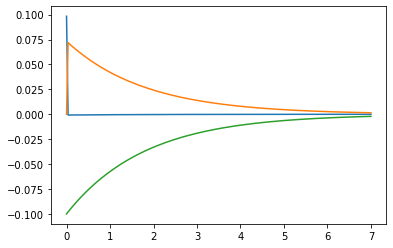

In [32]:
x0 = [0, 0, 0.0001, 1.0]
ks = [28.8, 984.0, 1093.0, 386.0, 1.75, 0.1]
ts = np.linspace(0, 7, 199)

xs, ys, rates = simulate(x0, ks, ts)

plt.plot(ts, rates.T)

array([0.   , 0.875, 1.75 , 2.625, 3.5  , 4.375, 5.25 , 6.125, 7.   ])